In [1]:
import os
import warnings
import numpy as np
import jax.numpy as jnp
from jaxcmr.analyses.distcrp import plot_dist_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [2]:
run_tag = "CatCRP"
data_tag = "CohenKahana2022_noELI"
data_path = "data/CohenKahana2022_noELI.h5"
data_query = "data['session'] == 1"
emotion_features_path = "data/emotion_features_7col.npy"

In [3]:
project_root = find_project_root()
data = load_data(os.path.join(project_root, data_path))
trial_mask = generate_trial_mask(data, data_query)

emotion_features = np.load(os.path.join(project_root, emotion_features_path)).astype(np.float32)
emotional_flag = emotion_features[:, 6].astype(np.int32)
emotion_distance = np.abs(emotional_flag[:, None] - emotional_flag[None, :]).astype(np.float32)

bin_edges = jnp.array([0.5], dtype=jnp.float32)
bin_centers = jnp.array([0.0, 1.0], dtype=jnp.float32)

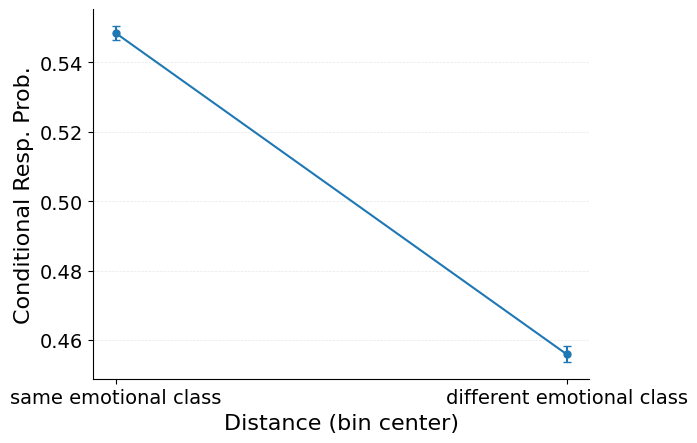

In [4]:
axis = plot_dist_crp(
    data,
    trial_mask,
    distances=emotion_distance,
    bin_edges=bin_edges,
    bin_centers=bin_centers,
)
axis.set_xticks(bin_centers)
axis.set_xticklabels(["same emotional class", "different emotional class"])
plt.show()